# CHIA preprocessing (Prep + EDA)

Turns the raw CHIA corpus (BRAT `.txt`/`.ann` files) into split, model-ready NER datasets, with every transformation shown inline.

**Pipeline:** raw `.ann` → parse to char-offset *fragments* → tokenize → resolve overlaps → BIO tags + char-offset spans → split by trial → write `data/processed_baseline/*.jsonl`.

Two things to know about the raw data:
- (2000 `.txt` + 2000 `.ann`, = 1000 trials × {inclusion, exclusion}). We use *without_scope* deliberately.
- Each `.txt` line is already one eligibility criterion (annotator-segmented), so we treat lines as sentences directly.

Outputs, per split, share the **same flattened gold entities** so a fine-tuned encoder and an LLM can later be scored against identical spans:
- `{split}.jsonl` — `tokens` + BIO `ner_tags`
- `{split}_spans.jsonl` — raw `text` + char-offset `entities`

In [23]:
import json
import random
import re
import statistics as stats_lib
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

In [24]:
PROJECT_ROOT = Path("/home/jatin/nlp/project")
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "without_scope"
OUT_DIR = PROJECT_ROOT / "data" / "processed_baseline" 

In [25]:
n_txt = len(list(RAW_DIR.glob("*.txt")))
n_ann = len(list(RAW_DIR.glob("*.ann")))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RAW_DIR:      {RAW_DIR}  ({n_txt} .txt, {n_ann} .ann)")
print(f"OUT_DIR:      {OUT_DIR}")
assert n_txt == n_ann == 2000

PROJECT_ROOT: /home/jatin/nlp/project
RAW_DIR:      /home/jatin/nlp/project/data/raw/without_scope  (2000 .txt, 2000 .ann)
OUT_DIR:      /home/jatin/nlp/project/data/processed_baseline


## Label schema (read from `annotation.conf`)

Rather than hardcode the entity types, we read them from CHIA's BRAT config, `data/raw/without_scope/annotation.conf`,
which groups types into `!CONCEPTS` (clinical entities), `!ANNOTATION` (modifiers), and `!ERROR` (annotator quality
flags — not entities). Following Li et al. 2022 we keep **CONCEPTS ∪ ANNOTATION** as an **allowlist** and drop everything else.

Two exclusions:
- **`Scope`** — listed under CONCEPTS in the config, but the *without_scope* release contains **0 `Scope` annotations** (verified), so it carries no labels here.
- **`Line`** — present in the data (100 mentions) but **absent from Li et al.'s reported CHIA entity set** (their Table 2; every other type's count matches ours exactly), so we drop it to match their 15-type set. Flip `EXCLUDE_TYPES` to keep it.

Using an allowlist matters: the raw data also carries undocumented junk tags (`Parsing_Error`, `Undefined_semantics`, `Subjective_judgement`, `Context_Error`, `Grammar_Error`, `Not_a_criteria`, …) that aren't even in the config's ERROR list, a blocklist would silently keep them.

In [26]:
CONF_PATH = RAW_DIR / "annotation.conf"

In [27]:
def load_entity_schema(conf_path: Path) -> dict[str, list[str]]:
    """Parse the [entities] section of a BRAT annotation.conf into its
    !GROUP -> [types] mapping (CONCEPTS / ANNOTATION / ERROR)."""
    groups: dict[str, list[str]] = {}
    in_entities, current = False, None
    for raw in conf_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if line.startswith("[") and line.endswith("]"):
            in_entities = (line == "[entities]")
            current = None
            continue
        if not in_entities or not line:
            continue
        if line.startswith("!"):                    # group header, e.g. !CONCEPTS
            current = line[1:].strip().upper()
            groups.setdefault(current, [])
        elif current is not None:                    # an entity type under the group
            groups[current].append(line)
    return groups

groups = load_entity_schema(CONF_PATH)

In [28]:
EXCLUDE_TYPES = {"Scope", "Line"}
CONCEPT_TYPES    = [t for t in groups.get("CONCEPTS", [])   if t not in EXCLUDE_TYPES]
ANNOTATION_TYPES = [t for t in groups.get("ANNOTATION", []) if t not in EXCLUDE_TYPES]
ERROR_TYPES      = groups.get("ERROR", [])
KEPT_ENTITY_TYPES = CONCEPT_TYPES + ANNOTATION_TYPES

In [29]:
LABELS = ["O"] + [f"{p}-{t}" for t in KEPT_ENTITY_TYPES for p in ("B", "I")]
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

In [30]:
SPLIT_SEED = 42

print("CONCEPTS:", groups.get("CONCEPTS"))
print("ANNOTATION:", groups.get("ANNOTATION"))
print("ERROR:", groups.get("ERROR"))

print(f"\nExcluded  : {sorted(EXCLUDE_TYPES)}")
print(f"KEPT ({len(KEPT_ENTITY_TYPES)}): {KEPT_ENTITY_TYPES}")
print(f"-> {len(LABELS)} BIO labels")

CONCEPTS: ['Scope', 'Person', 'Condition', 'Drug', 'Observation', 'Measurement', 'Procedure', 'Device', 'Visit']
ANNOTATION: ['Negation', 'Qualifier', 'Temporal', 'Value', 'Multiplier', 'Reference_point', 'Line', 'Mood']
ERROR: ['Non-query-able', 'Post-eligibility', 'Pregnancy_considerations', 'Competing_trial', 'Informed_consent', 'Intoxication_considerations', 'Non-representable']

Excluded  : ['Line', 'Scope']
KEPT (15): ['Person', 'Condition', 'Drug', 'Observation', 'Measurement', 'Procedure', 'Device', 'Visit', 'Negation', 'Qualifier', 'Temporal', 'Value', 'Multiplier', 'Reference_point', 'Mood']
-> 31 BIO labels


## Parse `.ann` → Fragments (merge disjoint mentions)

A **Fragment** is one entity mention as a single continuous character range. CHIA stores discontinuous mentions as one T-line with `;`-separated offset pairs
(e.g. `Condition 153 160;171 176` = "alcohol … abuse"). Li et al. 2022 **merge** these disjoint pieces into one continuous span (start of the first piece → end of
the last, gap included), converting CHIA to the continuous, non-overlapping entities their comparison assumes. Types outside the allowlist are dropped here.

In [31]:
_T_LINE_RE = re.compile(r"^(T\d+)\t(\S+) (.+?)\t(.*)$")

@dataclass(frozen=True)
class Fragment:
    """One entity mention as a single continuous character range."""
    entity_id: str
    type: str
    start: int
    end: int

def parse_ann(ann_text: str) -> list[Fragment]:
    """Parse a .ann file into entity mentions (T-lines only; kept types only).

    Following Li et al. 2022, discontinuous mentions (';'-separated offset pairs)
    are MERGED into one continuous span [min start, max end].
    """
    fragments = []
    for line in ann_text.splitlines():
        if not line or not line.startswith("T"):
            continue
        m = _T_LINE_RE.match(line)
        if not m:
            continue
        entity_id, entity_type, offset_str, _text = m.groups()
        if entity_type not in KEPT_ENTITY_TYPES:
            continue
        pieces = [tuple(map(int, seg.split())) for seg in offset_str.split(";")]
        start = min(s for s, _ in pieces)
        end = max(e for _, e in pieces)              # merge disjoint pieces
        fragments.append(Fragment(entity_id, entity_type, start, end))
    return fragments

In [32]:
# NCT00182520_exc has a discontinuous entity (T10) — good for illustration.
demo_stem = "NCT00182520_exc"
# read_bytes().decode() — NOT read_text() — so CRLF is preserved and char offsets match the .ann.
txt = (RAW_DIR / f"{demo_stem}.txt").read_bytes().decode("utf-8")
ann = (RAW_DIR / f"{demo_stem}.ann").read_text(encoding="utf-8")

print("=== .txt (first line = first criterion) ===")
print(txt.splitlines()[0])
print("\n=== .ann (first 6 T-lines) ===")
for line in [l for l in ann.splitlines() if l.startswith("T")][:6]:
    print(line)

=== .txt (first line = first criterion) ===
Any other primary DSM-IV diagnosis; DSM-IV criteria for body dysmorphic disorder, bipolar affective disorder, schizophrenia, psychotic disorder, current alcohol/substance abuse.

=== .ann (first 6 T-lines) ===
T1	Qualifier 18 24	DSM-IV
T2	Qualifier 10 17	primary
T3	Condition 25 34	diagnosis
T4	Measurement 36 51	DSM-IV criteria
T5	Condition 56 80	body dysmorphic disorder
T6	Condition 82 108	bipolar affective disorder


In [33]:
# Demo: the discontinuous T10 is now ONE continuous span (gap "/substance" included).
frags = parse_ann(ann)
print(f"{len(frags)} mentions parsed from {demo_stem}.ann\n")
for f in frags:
    if f.entity_id == "T10":
        print(f"{f}")
        print(f"raw offsets in .ann : 153 160;171 176  ('alcohol' + 'abuse')")
        print(f"merged text[{f.start}:{f.end}] = {txt[f.start:f.end]!r}")

27 mentions parsed from NCT00182520_exc.ann

Fragment(entity_id='T10', type='Condition', start=153, end=176)
raw offsets in .ann : 153 160;171 176  ('alcohol' + 'abuse')
merged text[153:176] = 'alcohol/substance abuse'


## Tokenizer (offset-preserving)

A lightweight regex tokenizer that keeps character offsets so entity spans can be aligned to tokens. It's intentionally simple — PubMedBERT's subword tokenizer re-tokenizes these
word tokens later (`is_split_into_words=True`). It treats hyphenated/apostrophe words (`biopsy-proven`, `patient's`) and decimals (`2.5`) as single tokens, and each standalone
symbol as its own token.

In [34]:
# Words (with internal -/'), decimals, or a single non-alphanumeric symbol.
_TOKEN_RE = re.compile(r"\d+\.\d+|[A-Za-z0-9]+(?:[-'][A-Za-z0-9]+)*|[^\sA-Za-z0-9]")

@dataclass(frozen=True)
class Token:
    text: str
    start: int
    end: int

def tokenize(text: str) -> list[Token]:
    return [Token(m.group(), m.start(), m.end()) for m in _TOKEN_RE.finditer(text)]

# Demo
for t in tokenize("Age >= 18 years; no biopsy-proven cancer."):
    print(f"  {t.text!r:16} [{t.start:2},{t.end:2})")

  'Age'            [ 0, 3)
  '>'              [ 4, 5)
  '='              [ 5, 6)
  '18'             [ 7, 9)
  'years'          [10,15)
  ';'              [15,16)
  'no'             [17,19)
  'biopsy-proven'  [20,33)
  'cancer'         [34,40)
  '.'              [40,41)


## Overlap resolution → BIO → spans

BIO is flat but CHIA has nesting, so — following Li et al. 2022's rule for nested entities — we **keep the outer (longest) entity** and drop shorter overlaps, yielding non-overlapping
spans. Then:
- `fragments_to_bio` labels each token whose char range overlaps a fragment (overlap, not exact match — annotator boundaries don't always land on token boundaries).
- `bio_to_spans` decodes BIO back to char-offset spans, so both the encoder and LLM pipelines can later be scored against the same flattened gold.

Note: because disjoint mentions were merged into continuous spans upstream, a merged span that bridges a gap can now contain a shorter entity and evict it here — an accepted fidelity cost of Li's "flatten to BIO" conversion.

In [35]:
def resolve_overlaps(fragments: list[Fragment]) -> list[Fragment]:
    """Greedily keep longest fragments, dropping any overlapping one already kept."""
    ordered = sorted(fragments, key=lambda f: (f.start - f.end, f.start))  # longest first
    kept: list[Fragment] = []
    for frag in ordered:
        if not any(frag.start < k.end and k.start < frag.end for k in kept):
            kept.append(frag)
    return sorted(kept, key=lambda f: f.start)

def fragments_to_bio(tokens: list[Token], fragments: list[Fragment]) -> list[str]:
    """Assign a BIO tag per token from non-overlapping fragments (char-overlap match)."""
    tags = ["O"] * len(tokens)
    for frag in fragments:
        first = True
        for i, tok in enumerate(tokens):
            if tok.start < frag.end and frag.start < tok.end:
                tags[i] = f"{'B' if first else 'I'}-{frag.type}"
                first = False
    return tags

def bio_to_spans(tokens: list[Token], tags: list[str]) -> list[dict]:
    """Decode BIO tags into char-offset entity spans."""
    spans, current = [], None
    for tok, tag in zip(tokens, tags):
        if tag.startswith("B-"):
            if current:
                spans.append(current)
            current = {"type": tag[2:], "start": tok.start, "end": tok.end}
        elif tag.startswith("I-") and current and tag[2:] == current["type"]:
            current["end"] = tok.end
        else:
            if current:
                spans.append(current)
            current = None
    if current:
        spans.append(current)
    return spans

In [36]:
# Demo: a nested Condition is dropped; a disjoint Visit is kept.
sample = "chronic kidney disease at screening visit"
demo_frags = [
    Fragment("A", "Condition", 0, 22),   # 'chronic kidney disease'  (longest -> kept)
    Fragment("B", "Condition", 8, 22),   # 'kidney disease'          (nested  -> dropped)
    Fragment("C", "Visit",    26, 41),   # 'screening visit'         (disjoint-> kept)
]
kept = resolve_overlaps(demo_frags)
dropped = [f for f in demo_frags if f not in kept]
print("KEPT:   ", [(f.entity_id, f.type, sample[f.start:f.end]) for f in kept])
print("DROPPED:", [(f.entity_id, f.type, sample[f.start:f.end]) for f in dropped])

toks = tokenize(sample)
tags = fragments_to_bio(toks, kept)
print("\ntokens:", [t.text for t in toks])
print("tags:  ", tags)
print("spans: ", [dict(s, text=sample[s['start']:s['end']]) for s in bio_to_spans(toks, tags)])

KEPT:    [('A', 'Condition', 'chronic kidney disease'), ('C', 'Visit', 'screening visit')]
DROPPED: [('B', 'Condition', 'kidney disease')]

tokens: ['chronic', 'kidney', 'disease', 'at', 'screening', 'visit']
tags:   ['B-Condition', 'I-Condition', 'I-Condition', 'O', 'B-Visit', 'I-Visit']
spans:  [{'type': 'Condition', 'start': 0, 'end': 22, 'text': 'chronic kidney disease'}, {'type': 'Visit', 'start': 26, 'end': 41, 'text': 'screening visit'}]


## Assemble sentence & document records

For each `.txt` keep only fragments fully inside the line, resolve overlaps, tag, and decode spans. `process_document` runs this over every line and stamps each record with `id`, `nct_id`, `criteria_type`. `discover_documents` finds every `NCT..._inc/_exc` `.txt`/`.ann` pair under the raw dir.

In [37]:
def discover_documents(raw_dir: Path) -> list[tuple[str, str, Path, Path]]:
    """Return (nct_id, criteria_type, txt_path, ann_path) for every doc pair."""
    docs = []
    for txt_path in sorted(raw_dir.glob("*.txt")):
        stem = txt_path.stem
        if stem.endswith("_inc"):
            nct_id, criteria_type = stem[:-len("_inc")], "inclusion"
        elif stem.endswith("_exc"):
            nct_id, criteria_type = stem[:-len("_exc")], "exclusion"
        else:
            continue
        ann_path = txt_path.with_suffix(".ann")
        if ann_path.exists():
            docs.append((nct_id, criteria_type, txt_path, ann_path))
    return docs

def iter_sentences(doc_text: str):
    """Yield (sentence_text, line_start_offset) for each non-blank line."""
    offset = 0
    for line in doc_text.splitlines(keepends=True):
        stripped = line.strip()
        if stripped:
            yield stripped, offset + (len(line) - len(line.lstrip()))
        offset += len(line)

def build_sentence_record(sentence_text: str, line_start: int, fragments: list[Fragment]) -> dict:
    local_fragments = [
        Fragment(f.entity_id, f.type, f.start - line_start, f.end - line_start)
        for f in fragments
        if line_start <= f.start and f.end <= line_start + len(sentence_text)
    ]
    tokens = tokenize(sentence_text)
    kept_fragments = resolve_overlaps(local_fragments)
    tags = fragments_to_bio(tokens, kept_fragments)
    spans = bio_to_spans(tokens, tags)
    for span in spans:
        span["text"] = sentence_text[span["start"]:span["end"]]
    return {
        "text": sentence_text,
        "tokens": [t.text for t in tokens],
        "ner_tags": tags,
        "entities": spans,
        "num_dropped_overlaps": len(local_fragments) - len(kept_fragments),
    }

def process_document(nct_id: str, criteria_type: str, txt_path: Path, ann_path: Path) -> list[dict]:
    # CRLF-safe: read raw bytes so \r\n is preserved and matches the absolute .ann offsets.
    # (read_text() applies universal-newline translation \r\n->\n, which shrinks the string
    # and drifts every criterion after line 0 by its line index — corrupting most entities.)
    doc_text = txt_path.read_bytes().decode("utf-8")
    fragments = parse_ann(ann_path.read_text(encoding="utf-8"))
    records = []
    for i, (sentence_text, line_start) in enumerate(iter_sentences(doc_text)):
        record = build_sentence_record(sentence_text, line_start, fragments)
        record.update(
            id=f"{nct_id}_{criteria_type[:3]}_{i}",
            nct_id=nct_id,
            criteria_type=criteria_type,
        )
        records.append(record)
    return records

In [38]:
# Run the full per-document pipeline on one exclusion file and show the first criterion.
recs = process_document("NCT00050349", "exclusion", RAW_DIR / "NCT00050349_exc.txt", RAW_DIR / "NCT00050349_exc.ann")
print(f"{len(recs)} sentence records\n")

r = recs[0]

print("id:      ", r["id"])
print("text:    ", r["text"])
print("tokens:  ", r["tokens"])
print("ner_tags:", r["ner_tags"])
print("entities:")

for e in r["entities"]:
    print("   ", e)

13 sentence records

id:       NCT00050349_exc_0
text:     Patients with symptomatic CNS metastases or leptomeningeal involvement
tokens:   ['Patients', 'with', 'symptomatic', 'CNS', 'metastases', 'or', 'leptomeningeal', 'involvement']
ner_tags: ['O', 'O', 'B-Qualifier', 'B-Condition', 'I-Condition', 'O', 'B-Condition', 'I-Condition']
entities:
    {'type': 'Qualifier', 'start': 14, 'end': 25, 'text': 'symptomatic'}
    {'type': 'Condition', 'start': 26, 'end': 40, 'text': 'CNS metastases'}
    {'type': 'Condition', 'start': 44, 'end': 70, 'text': 'leptomeningeal involvement'}


## Trial-level split (80/10/10, expressed as CV fold 0)

Split by **trial (NCT id)**, never by criterion inclusion/exclusion sentences from one trial must stay in the same split (else leakage). Li et al. used **10-fold CV**
(80/10/10 per fold) for evaluation; we emit that structure without paying for 10× files:

1. Assign every trial to one of **10 folds** (deterministic shuffle, `seed=42`) →
   saved as `fold_assignments.json`.
2. The concrete `train/val/test` we write here **is CV fold 0**:
   `test = fold 0`, `val = fold 1`, `train = folds 2–9` (= 80/10/10, matching Li's ratio).

Later, full 10-fold CV is reconstructed from the fold map: for fold *k*,
`test = k`, `val = (k+1) mod 10`, `train = the rest`.

In [39]:
N_FOLDS = 10

def assign_folds(nct_ids: list[str]) -> dict[str, int]:
    """Deterministically assign each unique trial to one of N_FOLDS folds."""
    trials = sorted(set(nct_ids))
    random.Random(SPLIT_SEED).shuffle(trials)
    base, rem = divmod(len(trials), N_FOLDS)
    fold_of, idx = {}, 0
    for f in range(N_FOLDS):
        size = base + (1 if f < rem else 0)           # spread remainder over first folds
        for t in trials[idx:idx + size]:
            fold_of[t] = f
        idx += size
    return fold_of

def split_from_folds(fold_of: dict[str, int], test_fold: int = 0, val_fold: int = 1) -> dict[str, str]:
    """Li's 80/10/10: one fold -> test, one -> val, the remaining eight -> train."""
    out = {}
    for t, f in fold_of.items():
        out[t] = "test" if f == test_fold else "val" if f == val_fold else "train"
    return out

# Demo + integrity checks
all_nct = [p.stem.rsplit("_", 1)[0] for p in RAW_DIR.glob("*.txt")]
fold_of = assign_folds(all_nct)
assignment = split_from_folds(fold_of)
print("fold sizes (trials):", dict(sorted(Counter(fold_of.values()).items())))
print("single split (trials):", dict(Counter(assignment.values())))
assert len(set(fold_of.values())) == N_FOLDS
assert set(assignment.values()) == {"train", "val", "test"}

fold sizes (trials): {0: 100, 1: 100, 2: 100, 3: 100, 4: 100, 5: 100, 6: 100, 7: 100, 8: 100, 9: 100}
single split (trials): {'test': 100, 'val': 100, 'train': 800}


## Build & write the Li-aligned dataset

Runs the full pipeline over all 2000 docs and writes to **`data/processed_baseline/`**: the 7 dataset files plus `fold_assignments.json`.

In [40]:
def write_jsonl(path: Path, records: list[dict]) -> None:
    with path.open("w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r) + "\n")

def build(raw_dir: Path, out_dir: Path) -> dict:
    docs = discover_documents(raw_dir)
    if not docs:
        raise FileNotFoundError(f"No .txt/.ann pairs found under {raw_dir}")

    all_records = []
    for nct_id, criteria_type, txt_path, ann_path in docs:
        all_records.extend(process_document(nct_id, criteria_type, txt_path, ann_path))

    fold_of = assign_folds([r["nct_id"] for r in all_records])
    split_by_doc = split_from_folds(fold_of)          # single split = CV fold 0
    for r in all_records:
        r["split"] = split_by_doc[r["nct_id"]]

    out_dir.mkdir(parents=True, exist_ok=True)
    counts = {}
    for split in ("train", "val", "test"):
        split_records = [r for r in all_records if r["split"] == split]
        counts[split] = len(split_records)
        write_jsonl(out_dir / f"{split}.jsonl", [
            {"id": r["id"], "nct_id": r["nct_id"], "criteria_type": r["criteria_type"],
             "tokens": r["tokens"], "ner_tags": r["ner_tags"]}
            for r in split_records
        ])
        write_jsonl(out_dir / f"{split}_spans.jsonl", [
            {"id": r["id"], "nct_id": r["nct_id"], "criteria_type": r["criteria_type"],
             "text": r["text"], "entities": r["entities"]}
            for r in split_records
        ])

    (out_dir / "label_list.json").write_text(json.dumps(
        {"labels": LABELS, "label2id": {l: i for i, l in enumerate(LABELS)}}, indent=2))

    # Fold map for reconstructing Li's 10-fold CV later.
    (out_dir / "fold_assignments.json").write_text(json.dumps({
        "n_folds": N_FOLDS,
        "seed": SPLIT_SEED,
        "reconstruction": "fold k: test=k, val=(k+1)%n_folds, train=the rest",
        "single_split_here": {"test_fold": 0, "val_fold": 1},
        "trial_fold": dict(sorted(fold_of.items())),
    }, indent=2))

    return {
        "num_documents": len(docs),
        "num_trials": len(fold_of),
        "num_sentences": len(all_records),
        "split_counts_sentences": counts,
        "fold_sizes_trials": dict(sorted(Counter(fold_of.values()).items())),
        "num_overlaps_dropped": sum(r["num_dropped_overlaps"] for r in all_records),
    }

summary = build(RAW_DIR, OUT_DIR)
print(json.dumps(summary, indent=2))
assert summary["num_sentences"] == 12409 and summary["num_trials"] == 1000

{
  "num_documents": 2000,
  "num_trials": 1000,
  "num_sentences": 12409,
  "split_counts_sentences": {
    "train": 10006,
    "val": 1240,
    "test": 1163
  },
  "fold_sizes_trials": {
    "0": 100,
    "1": 100,
    "2": 100,
    "3": 100,
    "4": 100,
    "5": 100,
    "6": 100,
    "7": 100,
    "8": 100,
    "9": 100
  },
  "num_overlaps_dropped": 3638
}


## Guardrail: gold-mention placement check

Regression guard for the CRLF offset bug. Every gold mention must fall inside exactly one
criterion line; if `.txt` is read with newline translation (`read_text`), the `.ann` offsets
drift and mentions silently fall outside their line. This asserts that <1% are lost, using
the same CRLF-safe reader (`read_bytes().decode()`) that `process_document` uses.

In [41]:
# Independent check that gold mentions can be placed on a line (see process_document's reader note).
raw = placeable = 0
for _nct, _ct, tp, ap in discover_documents(RAW_DIR):
    frs = parse_ann(ap.read_text(encoding="utf-8")); raw += len(frs)
    doc = tp.read_bytes().decode("utf-8")   # CRLF-safe, matches .ann offsets
    for sent, ls in iter_sentences(doc):
        placeable += sum(1 for f in frs if ls <= f.start and f.end <= ls + len(sent))
lost = raw - placeable
print(f"gold mentions: {raw} | placeable on a line: {placeable} | lost: {lost} ({100*lost/raw:.2f}%)")
assert lost / raw < 0.01, "More than 1% of gold mentions fall outside line spans — likely a .txt newline/offset bug."

gold mentions: 40976 | placeable on a line: 40965 | lost: 11 (0.03%)


## Sanity stats per split

Entity-type counts and document/sentence totals per split, read back from the written `_spans.jsonl` files — the numbers that go into the paper's dataset table.

In [42]:
import pandas as pd

def summarize(out_dir: Path) -> dict:
    summary = {}
    for split in ("train", "val", "test"):
        path = out_dir / f"{split}_spans.jsonl"
        if not path.exists():
            continue
        sentences, nct_ids, type_counts = 0, set(), Counter()
        for line in path.read_text(encoding="utf-8").splitlines():
            record = json.loads(line)
            sentences += 1
            nct_ids.add(record["nct_id"])
            type_counts.update(e["type"] for e in record["entities"])
        summary[split] = {
            "sentences": sentences,
            "documents": len(nct_ids),
            "entities_total": sum(type_counts.values()),
            "entities_by_type": dict(type_counts.most_common()),
        }
    return summary

summ = summarize(OUT_DIR)
for split, d in summ.items():
    print(f"{split:5}: {d['documents']:4} trials | {d['sentences']:5} sentences | {d['entities_total']:6} entities")

# Per-type counts as a table
rows = [{"split": s, "type": t, "count": c}
        for s, d in summ.items() for t, c in d["entities_by_type"].items()]
df = (pd.DataFrame(rows)
        .pivot_table(index="type", columns="split", values="count", fill_value=0)
        .reindex(columns=["train", "val", "test"])
        .sort_values("train", ascending=False)
        .astype(int))
df.loc["TOTAL"] = df.sum()
df

train:  800 trials | 10006 sentences |  29985 entities
val  :  100 trials |  1240 sentences |   3707 entities
test :  100 trials |  1163 sentences |   3575 entities


split,train,val,test
type,,,
Condition,8888,1044,1121
Qualifier,3182,393,351
Value,3128,346,384
Temporal,2814,341,320
Drug,2761,434,292
Measurement,2544,258,310
Procedure,2514,306,305
Person,1204,177,152
Observation,868,132,113


## Exploratory data analysis

Sentence length, entity density, inclusion-vs-exclusion breakdown, and OOV rate vs. train. The `128`-token line on the length histogram is the fine-tuning `max_length` — very few
sentences exceed it, so plain truncation is safe.

`oov_token_rate_vs_train` is *naive whole-word* overlap against the train vocabulary; it overstates the true subword `[UNK]` rate (~0 for PubMedBERT's WordPiece tokenizer), so read it as a rough lexical-shift signal, not a literal OOV rate.

In [43]:
def _load_jsonl(path: Path) -> list[dict]:
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines()]

def analyze(out_dir: Path) -> dict:
    result = {}
    train_tokens = _load_jsonl(out_dir / "train.jsonl")
    train_vocab = {tok.lower() for r in train_tokens for tok in r["tokens"]}

    for split in ("train", "val", "test"):
        token_records = _load_jsonl(out_dir / f"{split}.jsonl")
        span_records = _load_jsonl(out_dir / f"{split}_spans.jsonl")

        sent_lengths = [len(r["tokens"]) for r in token_records]
        entity_counts = [len(r["entities"]) for r in span_records]
        by_criteria_type = Counter(r["criteria_type"] for r in span_records)
        entities_per_criteria_type = {}
        for ctype in ("inclusion", "exclusion"):
            subset = [len(r["entities"]) for r in span_records if r["criteria_type"] == ctype]
            entities_per_criteria_type[ctype] = round(sum(subset) / len(subset), 2) if subset else 0.0

        split_vocab = {tok.lower() for r in token_records for tok in r["tokens"]}
        oov_rate = (len(split_vocab - train_vocab) / len(split_vocab)
                    if split_vocab and split != "train" else 0.0)

        result[split] = {
            "sentences": len(token_records),
            "documents": len({r["nct_id"] for r in token_records}),
            "sentence_len_tokens": {
                "mean": round(stats_lib.mean(sent_lengths), 2),
                "median": stats_lib.median(sent_lengths),
                "p90": stats_lib.quantiles(sent_lengths, n=10)[8],
                "max": max(sent_lengths),
            },
            "entities_per_sentence": {
                "mean": round(stats_lib.mean(entity_counts), 2),
                "zero_entity_sentences_pct": round(
                    100 * sum(1 for c in entity_counts if c == 0) / len(entity_counts), 1),
            },
            "criteria_type_counts": dict(by_criteria_type),
            "mean_entities_per_sentence_by_criteria_type": entities_per_criteria_type,
            "unique_tokens": len(split_vocab),
            "oov_token_rate_vs_train": round(oov_rate, 3),
        }
    return result

report = analyze(OUT_DIR)
print(json.dumps(report, indent=2))

{
  "train": {
    "sentences": 10006,
    "documents": 800,
    "sentence_len_tokens": {
      "mean": 14.31,
      "median": 10.0,
      "p90": 30.0,
      "max": 421
    },
    "entities_per_sentence": {
      "mean": 3.0,
      "zero_entity_sentences_pct": 13.0
    },
    "criteria_type_counts": {
      "exclusion": 6348,
      "inclusion": 3658
    },
    "mean_entities_per_sentence_by_criteria_type": {
      "inclusion": 3.02,
      "exclusion": 2.98
    },
    "unique_tokens": 10106,
    "oov_token_rate_vs_train": 0.0
  },
  "val": {
    "sentences": 1240,
    "documents": 100,
    "sentence_len_tokens": {
      "mean": 14.89,
      "median": 10.0,
      "p90": 32.0,
      "max": 136
    },
    "entities_per_sentence": {
      "mean": 2.99,
      "zero_entity_sentences_pct": 16.0
    },
    "criteria_type_counts": {
      "exclusion": 762,
      "inclusion": 478
    },
    "mean_entities_per_sentence_by_criteria_type": {
      "inclusion": 2.75,
      "exclusion": 3.14
    },
  

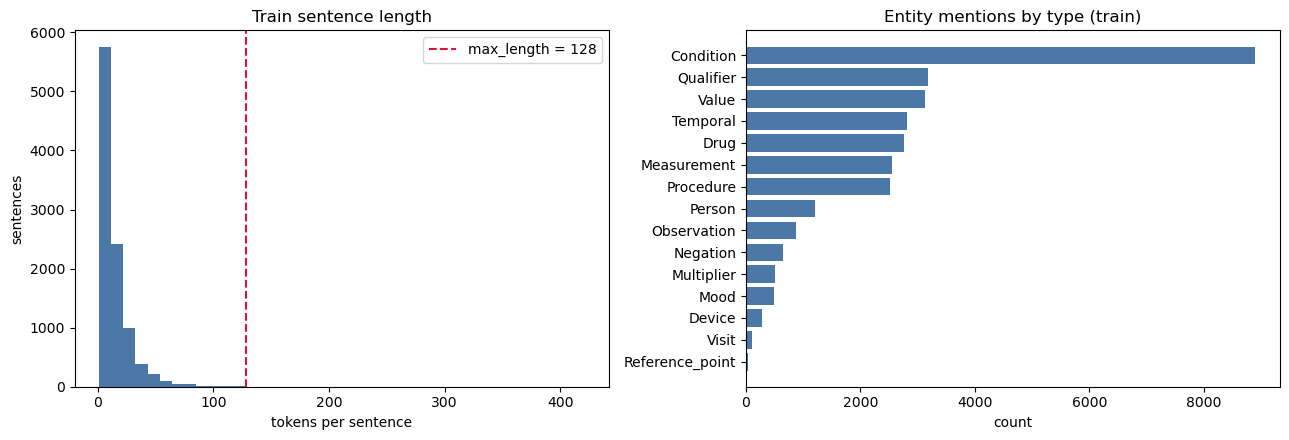

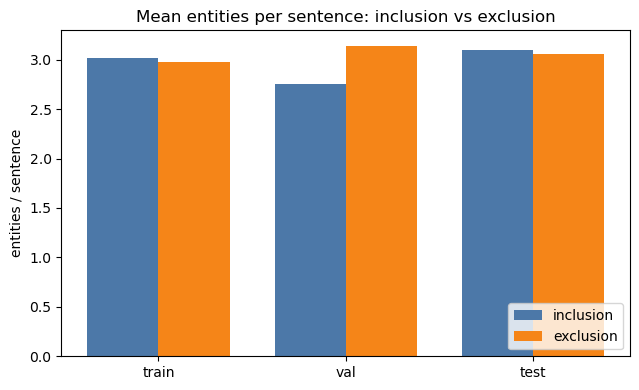

In [44]:
import matplotlib.pyplot as plt
import numpy as np

train = _load_jsonl(OUT_DIR / "train.jsonl")
lengths = [len(r["tokens"]) for r in train]
train_counts = summ["train"]["entities_by_type"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) sentence length distribution
axes[0].hist(lengths, bins=40, color="#4C78A8")
axes[0].axvline(128, color="crimson", ls="--", lw=1.5, label="max_length = 128")
axes[0].set(title="Train sentence length", xlabel="tokens per sentence", ylabel="sentences")
axes[0].legend()

# (b) entity mentions by type (train)
types = list(train_counts)[::-1]
axes[1].barh(types, [train_counts[t] for t in types], color="#4C78A8")
axes[1].set(title="Entity mentions by type (train)", xlabel="count")

plt.tight_layout()
plt.show()

# (c) entity density: inclusion vs exclusion, per split
splits = ["train", "val", "test"]
inc = [report[s]["mean_entities_per_sentence_by_criteria_type"]["inclusion"] for s in splits]
exc = [report[s]["mean_entities_per_sentence_by_criteria_type"]["exclusion"] for s in splits]
x, w = np.arange(len(splits)), 0.38

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(x - w/2, inc, w, label="inclusion", color="#4C78A8")
ax.bar(x + w/2, exc, w, label="exclusion", color="#F58518")
ax.set_xticks(x, splits)
ax.set(title="Mean entities per sentence: inclusion vs exclusion", ylabel="entities / sentence")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Summary

`data/processed_baseline/` now holds the **Li et al. 2022-aligned** dataset:
- `{train,val,test}.jsonl` — BIO tokens (single 80/10/10 split = CV fold 0)
- `{train,val,test}_spans.jsonl` — char-offset gold spans (shared scoring / LLM prompting)
- `label_list.json` — the BIO label vocabulary (from `annotation.conf`)
- `fold_assignments.json` — trial→fold map to reconstruct the full 10-fold CV

**Alignment with Li et al. 2022:** without_scope source, BIO, keep-outer for nested,
**merge disjoint into continuous**, entity types read from the config (15 types; `Scope`/`Line` excluded), inc+exc grouped by trial, 80/10/10 ratio.
**Documented deviations:** sentence-splitting/tokenization is line-based + regex (Li used the CLAMP toolkit, unavailable here), and CV is emitted as a fold map rather than 10 materialized copies.